In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df_out = pd.read_csv('outputs/predictions_exit_velo_2024.csv')

print(df_out.head())

   batter_id  predicted_exit_velo  pred_std  pred_lower  pred_upper
0       2432            84.922929  1.943990   80.867989   88.669653
1       3814            84.944671  1.883575   81.134752   88.588967
2       3562            84.834976  1.925897   80.815759   88.548169
3        798            84.911261  1.960328   81.091470   89.119949
4       3798            84.607205  1.881018   81.069011   88.518103


In [10]:
!pwd

/Users/mariaoros/Documents/Github-projects/2025/Miami-marlins-challenge/3_Modeling/uncertainty_quantification


In [13]:
validate = pd.read_csv('/Users/mariaoros/Documents/Github-projects/2025/Miami-marlins-challenge/1_Data/exit_velo_validate_data.csv')
print(validate.head(5))

   season  batter_id   age
0    2024          2  25.4
1    2024          6  29.2
2    2024          9  22.3
3    2024         11  26.8
4    2024         12  34.8


In [14]:
merge_w_validate = validate.merge(df, on='batter_id', how='left')


print(len(merge_w_validate), len(validate))

647 647


In [16]:
len(merge_w_validate[merge_w_validate['predicted_exit_velo'].isna()])

60

In [17]:
# No prediction
merge_w_validate[merge_w_validate['predicted_exit_velo'].isna()]

,season,batter_id,age,predicted_exit_velo,pred_std,pred_lower,pred_upper
2,2024,9,22.3,NaN,NaN,NaN,NaN
10,2024,45,26.6,NaN,NaN,NaN,NaN
46,2024,288,26.5,NaN,NaN,NaN,NaN
53,2024,311,27.3,NaN,NaN,NaN,NaN
69,2024,390,23.9,NaN,NaN,NaN,NaN
70,2024,401,29.8,NaN,NaN,NaN,NaN
78,2024,425,26.1,NaN,NaN,NaN,NaN
88,2024,526,24.8,NaN,NaN,NaN,NaN
100,2024,580,24.7,NaN,NaN,NaN,NaN
108,2024,652,31.9,NaN,NaN,NaN,NaN


In [18]:
import seaborn as sns

<Axes: xlabel='age', ylabel='predicted_exit_velo'>

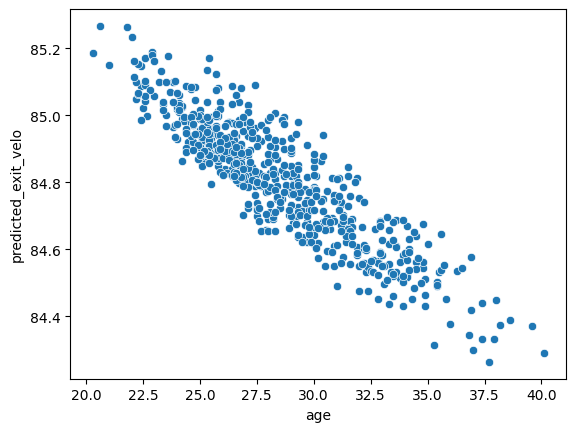

In [19]:
sns.scatterplot(data=merge_w_validate, x="age", y="predicted_exit_velo")

In [40]:
df_in = (
        df.groupby(['batter_id'])['exit_velo']
        .agg(['mean', 'count', 'std'])
        .reset_index()
    )
df_in.columns = ['batter_id', 'mean_exit_velo', 'count_events', 'std_exit_velo']

all_tog = merge_w_validate.merge(df_in, on='batter_id', how='left')


print(len(all_tog), len(merge_w_validate))

647 647


In [41]:
all_tog.columns

Index(['season', 'batter_id', 'age', 'predicted_exit_velo', 'pred_std',
       'pred_lower', 'pred_upper', 'mean_exit_velo', 'count_events',
       'std_exit_velo'],
      dtype='object')

<Axes: xlabel='mean_exit_velo', ylabel='predicted_exit_velo'>

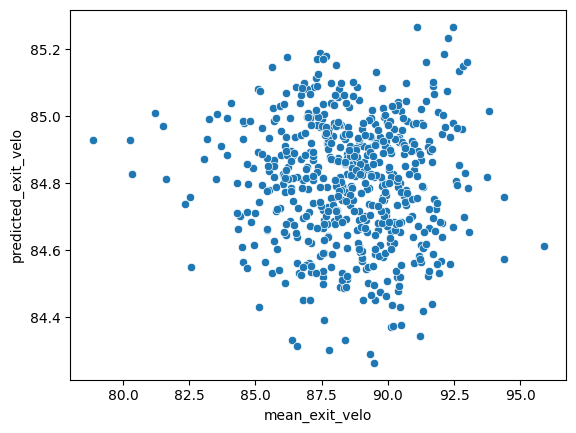

In [43]:
sns.scatterplot(data=all_tog, x="mean_exit_velo", y="predicted_exit_velo")


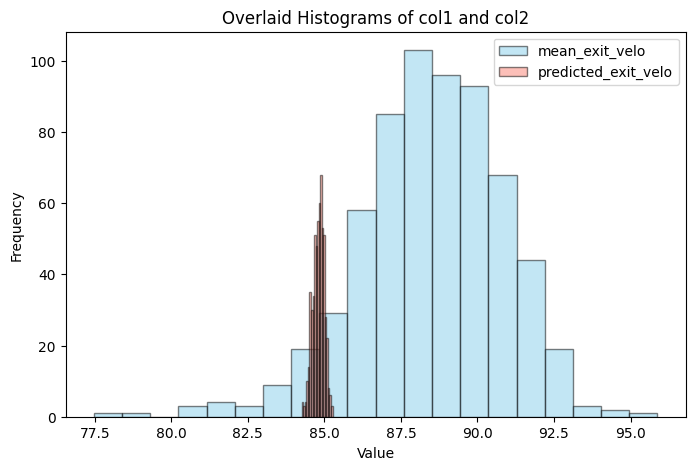

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
#data=all_tog, x="mean_exit_velo", y="predicted_exit_velo")
plt.hist(all_tog["mean_exit_velo"], bins=20, alpha=0.5, label="mean_exit_velo", color="skyblue", edgecolor="black")
plt.hist(all_tog["predicted_exit_velo"], bins=20, alpha=0.5, label="predicted_exit_velo", color="salmon", edgecolor="black")

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Overlaid Histograms of col1 and col2")
plt.legend()
plt.show()


## Evaluation

In [22]:
df_out = pd.read_csv('/Users/mariaoros/Documents/Github-projects/2025/Miami-marlins-challenge/3_Modeling/uncertainty_quantification/outputs/predictions_exit_velo_2024.csv')

print(df_out.head())

   batter_id  predicted_exit_velo  pred_std  pred_lower  pred_upper
0       2432            84.922929  1.943990   80.867989   88.669653
1       3814            84.944671  1.883575   81.134752   88.588967
2       3562            84.834976  1.925897   80.815759   88.548169
3        798            84.911261  1.960328   81.091470   89.119949
4       3798            84.607205  1.881018   81.069011   88.518103


In [24]:
df = pd.read_csv('/Users/mariaoros/Documents/Github-projects/2025/Miami-marlins-challenge/1_Data/exit_velo_project_data.csv')

 ====================== TOP BATTERS 2725


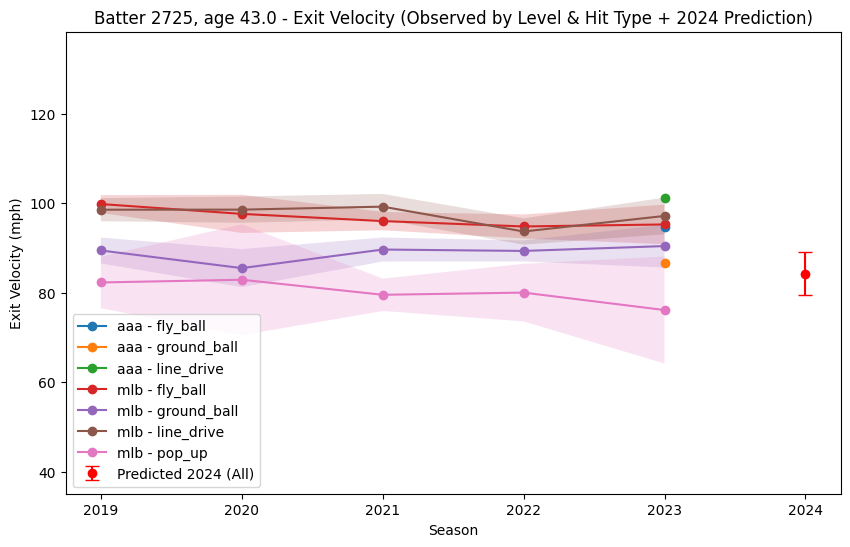

 ====================== TOP BATTERS 3329


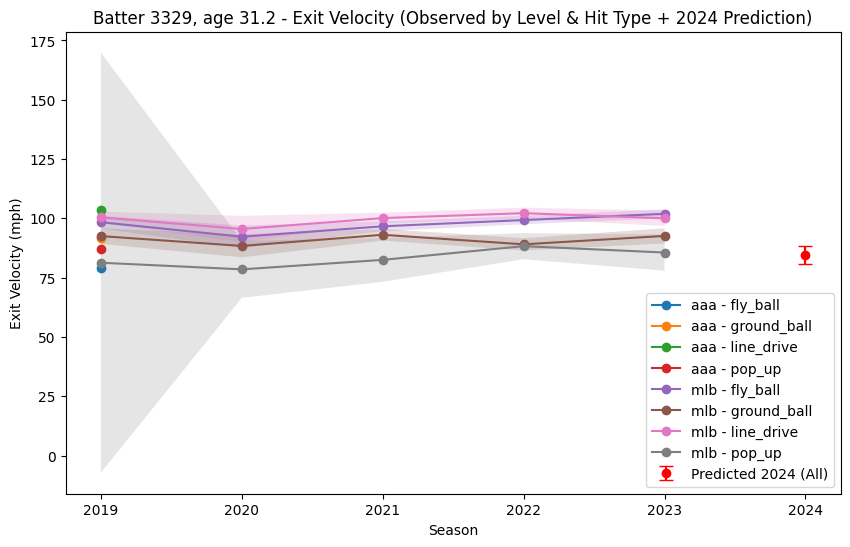

 ====================== TOP BATTERS 2441


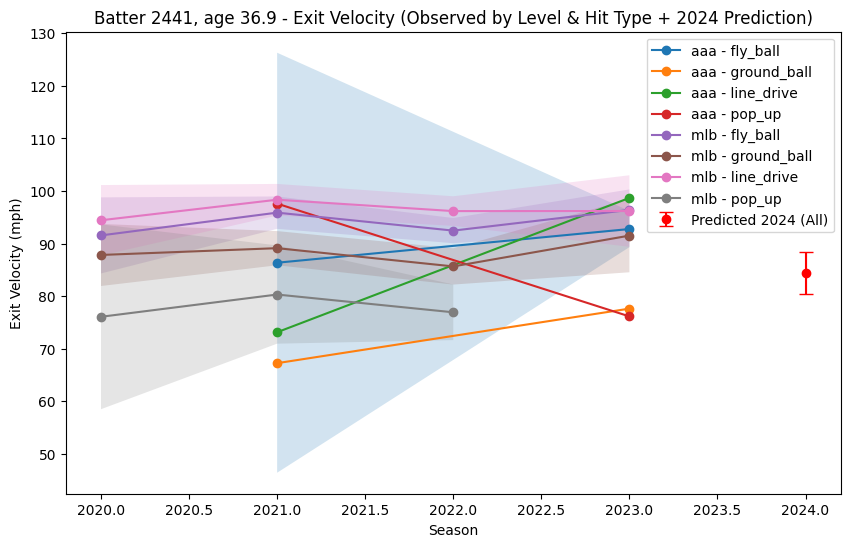

 ====================== TOP BATTERS 2334


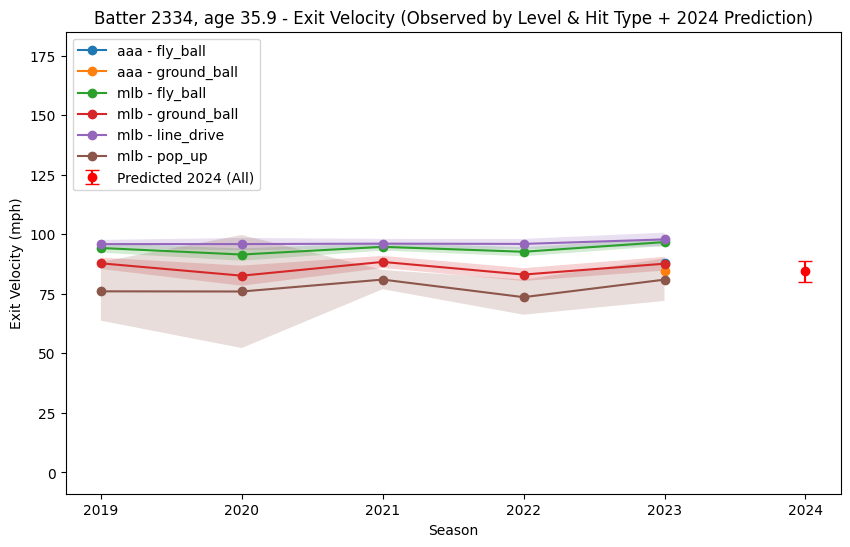

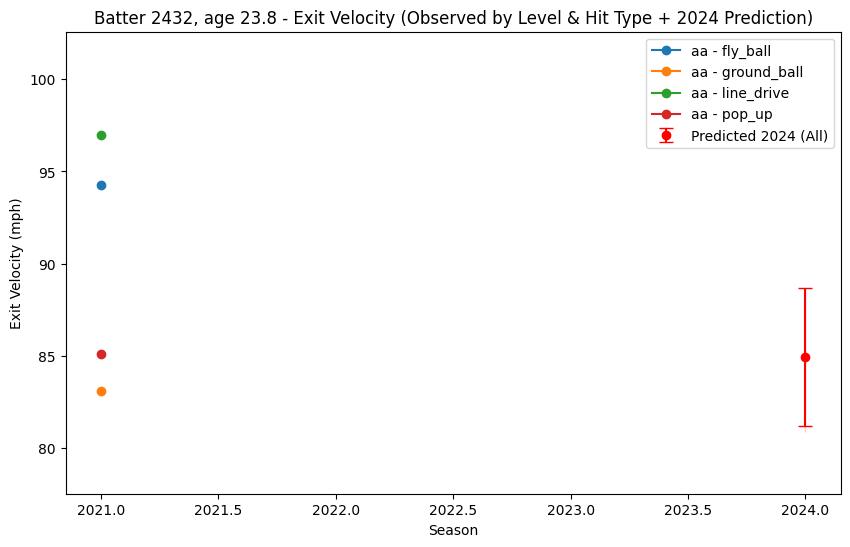

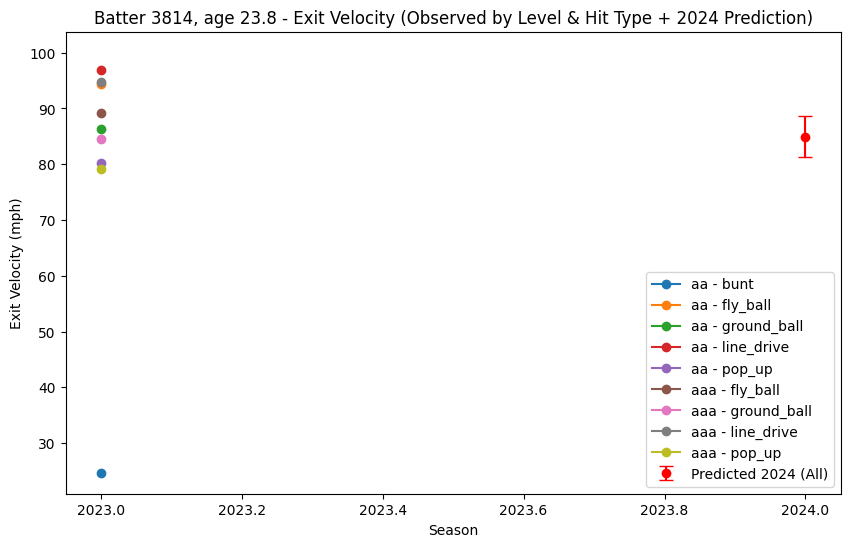

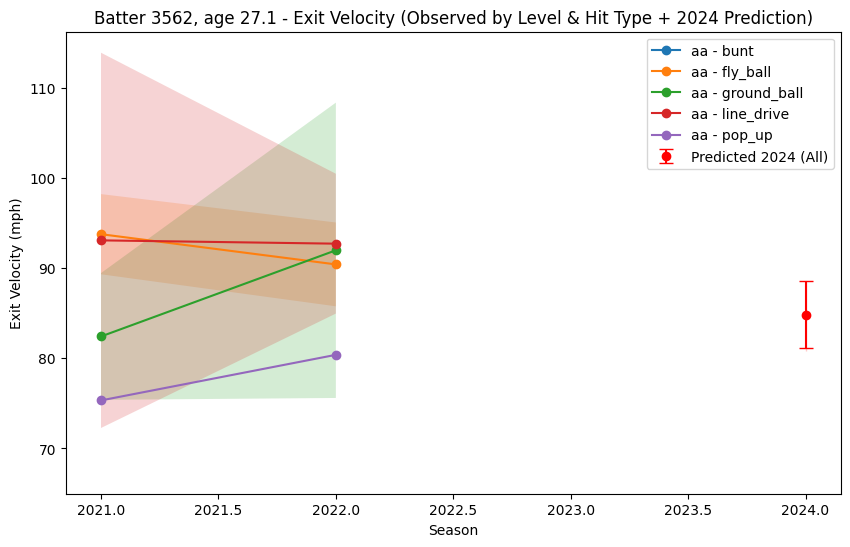

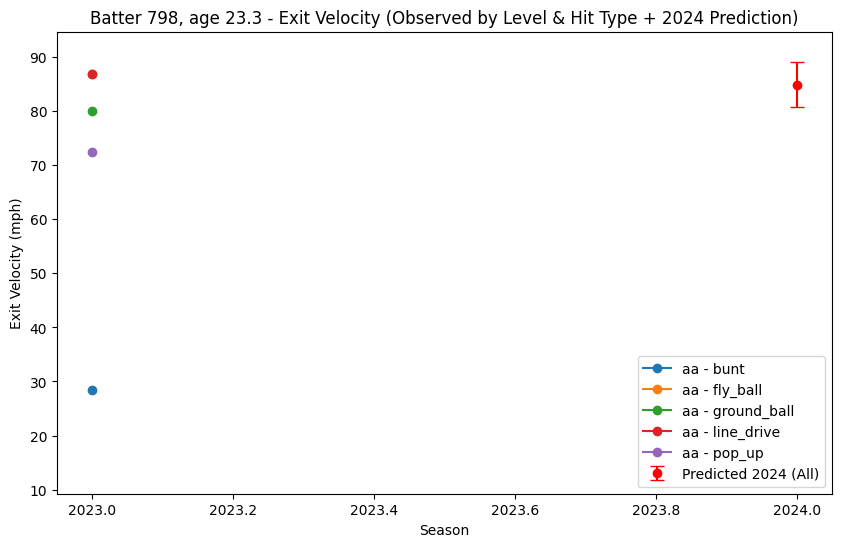

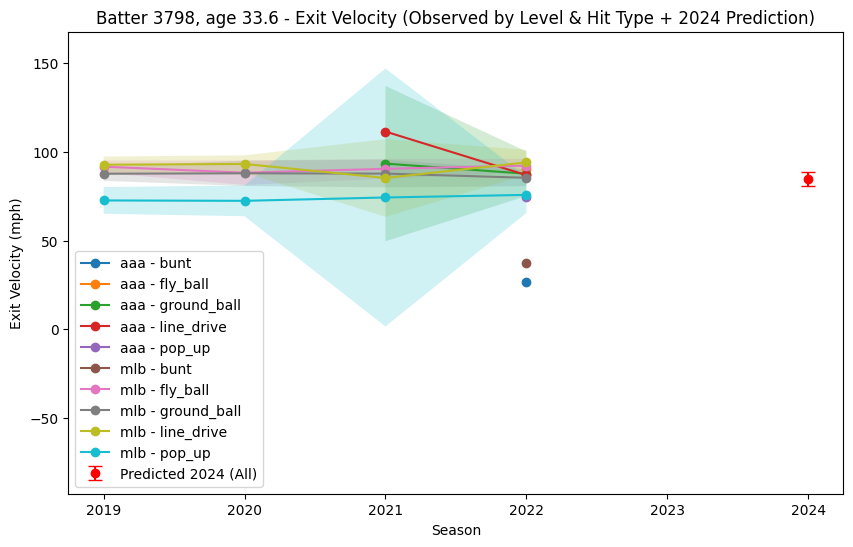

In [34]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ---- Example predictions ----
top_batters = [2725, 3329,2441,2334]
example_batters = [2432,3814,3562,798,3798]
preds = df_out[df_out['batter_id'].isin(top_batters+example_batters)]


# ---- Function to compute observed + prediction summary ----
def make_summary_with_prediction(df, batter_id, preds):

    df_batter = df[df['batter_id'] == batter_id]
    # Group by season, level_abbr, and hit_type
    summary = (
        df_batter.groupby(['season', 'level_abbr', 'hit_type'])['exit_velo']
        .agg(['mean', 'count', 'std'])
        .reset_index()
    )

    # Compute CI for observed
    confidence = 0.95
    summary['sem'] = summary['std'] / np.sqrt(summary['count'])
    ci_bounds = stats.t.ppf((1 + confidence) / 2., summary['count'] - 1)
    summary['ci'] = summary['sem'] * ci_bounds
    summary['lower'] = summary['mean'] - summary['ci']
    summary['upper'] = summary['mean'] + summary['ci']

    # Add prediction row — note: no hit_type split in preds, so leave NaN or "All"
    pred = preds.loc[preds['batter_id'] == batter_id].iloc[0]
    pred_row = {
        "season": 2024,
        "level_abbr": "Predicted",
        "hit_type": "All",
        "mean": pred['predicted_exit_velo'],
        "count": np.nan,
        "std": np.nan,
        "sem": pred['pred_std'],
        "ci": pred['pred_upper'] - pred['predicted_exit_velo'],
        "lower": pred['pred_lower'],
        "upper": pred['pred_upper']
    }
    summary = pd.concat([summary, pd.DataFrame([pred_row])], ignore_index=True)

    return summary


# ---- Plot function ----
def plot_batter(df, batter_id, preds):
    summary = make_summary_with_prediction(df, batter_id, preds)

    plt.figure(figsize=(10,6))

    # Loop over level_abbr and hit_type
    for (lvl, hit), grp in summary.groupby(["level_abbr", "hit_type"]):
        if grp['season'].max() == 2024 and lvl == "Predicted":
            # Predicted row in red
            plt.errorbar(grp['season'], grp['mean'],
                         yerr=grp['ci'], fmt='o', color='red', capsize=5,
                         label=f"Predicted 2024 ({hit})")
            plt.fill_between(grp['season'], grp['lower'], grp['upper'], color='red', alpha=0.2)
        else:
            # Observed in blue variations
            plt.plot(grp['season'], grp['mean'], marker='o', label=f"{lvl} - {hit}")
            plt.fill_between(grp['season'], grp['lower'], grp['upper'], alpha=0.2)

    plt.xlabel("Season")
    plt.ylabel("Exit Velocity (mph)")
    plt.title(f"Batter {batter_id}, age {df[df['batter_id']==batter_id].age.max()} - Exit Velocity (Observed by Level & Hit Type + 2024 Prediction)")
    plt.legend()
    plt.show()


# ---- Loop over batters ----
for batter_id in top_batters+example_batters:
    if batter_id in example_batters:
        pass
    else:
        print(f" ====================== TOP BATTERS {batter_id}")
    plot_batter(df, batter_id, preds)
